In [1]:
import sys
from pathlib import Path
import pandas as pd

# 1. Compute project root (one level up from notebooks/)
project_root = Path.cwd().parent

# 2. Make src/ importable
sys.path.insert(0, str(project_root / "src"))

# 3. Define where your data lives
data_dir = project_root / "data"

# 4. Read your CSV
df = pd.read_csv(data_dir / "banking_complaints.csv")
df.head()



,Complaint ID,Date Received,Banking Product,Issue ID,Complaint Description,State,ZIP,Bank Response
0,CID76118977,1/1/2023,Checking or savings account,I_3510635,on XX/XX/XX22 I opened a safe balance account ...,California,92311,Closed with monetary relief
1,CID98703933,1/1/2023,"Credit reporting, credit repair services, or o...",I_3798538,There is an item from Bank of ABC on my credit...,California,91344,Closed with explanation
2,CID52036665,1/1/2023,Checking or savings account,I_3648593,On XX/XX/XX22 I found out that my account was ...,New York,10466,Closed with monetary relief
3,CID62581335,1/1/2023,Credit card or prepaid card,I_6999080,I've had a credit card for years with Bank of ...,California,92127,Closed with monetary relief
4,CID65731164,1/1/2023,Checking or savings account,I_3648593,This issue has to do with the way that Bank of...,New Jersey,7946,Closed with explanation


In [2]:
# 1) Load mapping
dept_map = pd.read_csv(data_dir/"dept_product.csv")
# Should show columns ['Product', 'Department']
print("Mapping columns:", dept_map.columns.tolist())

# 2) Merge (rename Department → department)
df = df.merge(
    dept_map.rename(columns={
        "Product":    "Banking Product",
        "Department": "department"
    }),
    on="Banking Product",
    how="left"
)

# 3) Verify merge
print("Columns after merge:", df.columns.tolist())
print("Unique departments:", df['department'].unique())



Mapping columns: ['Product', 'Department']
Columns after merge: ['Complaint ID', 'Date Received', 'Banking Product', 'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response', 'department']
Unique departments: ['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage'
 nan 'Others']


In [3]:
# See exactly which product names failed to map
unmapped = df.loc[df["department"].isna(), "Banking Product"].unique()
print("Unmapped products:", unmapped)


Unmapped products: ['Credit reporting' 'Credit card' 'Bank account or service'
 'Consumer Loan' 'Money transfers' 'Payday loan' 'Prepaid card']


In [4]:
# ── Handle any remaining unmapped products ──

# See which products failed to map
unmapped = df.loc[df["department"].isna(), "Banking Product"].unique()
print("Unmapped products:", unmapped)

# Define a small synonym map for those variants
syn_map = {
    "Credit reporting":      "Credit Reports",
    "Credit card":           "Credit Cards",
    "Prepaid card":          "Credit Cards",
    "Consumer Loan":         "Loans",
    "Payday loan":           "Loans",
    "Bank account or service": "CASA",
    "Money transfers":       "Remittance"
}

# Fill the missing departments using the synonym map
df["department"] = df["department"].fillna(df["Banking Product"].map(syn_map))

# Verify that all rows now have a department
missing_after = df["department"].isna().sum()
print(f"Rows still unmapped after synonyms: {missing_after}")

# If zero, you’re good to go—otherwise inspect again:
if missing_after > 0:
    print(df.loc[df["department"].isna(), "Banking Product"].unique())


Unmapped products: ['Credit reporting' 'Credit card' 'Bank account or service'
 'Consumer Loan' 'Money transfers' 'Payday loan' 'Prepaid card']
Rows still unmapped after synonyms: 0


In [5]:
# Just to confirm no more NaNs in department
print(df["department"].unique())


['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage'
 'Others']


In [6]:
# Download NLTK data (one-time)
import nltk

# Stopwords for filtering, WordNet + omw for lemmatization
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/sheilamcgovern/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [7]:
from data_utils import load_data, check_types
from preprocess   import preprocessing

df = load_data(project_root/"data"/"banking_complaints.csv")

# check types & missing
check_types(df)

# apply preprocessing to the complaint text
df['cleaned_description'] = df['Complaint Description'].fillna("").apply(preprocessing)
df[['Complaint Description','cleaned_description']].head()


Complaint ID             object
Date Received            object
Banking Product          object
Issue ID                 object
Complaint Description    object
State                    object
ZIP                      object
Bank Response            object
dtype: object

Missing values per column:
Complaint ID              0
Date Received             0
Banking Product           0
Issue ID                  0
Complaint Description     0
State                    27
ZIP                      30
Bank Response             0
dtype: int64


,Complaint Description,cleaned_description
0,on XX/XX/XX22 I opened a safe balance account ...,xx xx xx opened safe balance account online ...
1,There is an item from Bank of ABC on my credit...,item bank abc credit report belong must remove...
2,On XX/XX/XX22 I found out that my account was ...,xx xx xx found account frozen apparent reaso...
3,I've had a credit card for years with Bank of ...,'ve credit card year bank abc xx xx xxxx paid ...
4,This issue has to do with the way that Bank of...,issue way bank abc account linking bill pay pa...


In [8]:
# Convert Date Received to datetime
df['Date Received'] = pd.to_datetime(df['Date Received'], errors='coerce')

# Check the conversion
print(df['Date Received'].dtype)
print("Date range:", df['Date Received'].min(), "→", df['Date Received'].max())


datetime64[ns]
Date range: 2023-01-01 00:00:00 → 2023-10-21 00:00:00


In [9]:
from pathlib import Path
import pandas as pd

#–– set project_root to one level up from wherever your notebook lives
project_root = Path.cwd().parent  

#–– load & peek
df = pd.read_csv(project_root/"data"/"banking_complaints.csv")
df.head()

#–– check types and nulls
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7011 entries, 0 to 7010
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Complaint ID           7011 non-null   object
 1   Date Received          7011 non-null   object
 2   Banking Product        7011 non-null   object
 3   Issue ID               7011 non-null   object
 4   Complaint Description  7011 non-null   object
 5   State                  6984 non-null   object
 6   ZIP                    6981 non-null   object
 7   Bank Response          7011 non-null   object
dtypes: object(8)
memory usage: 438.3+ KB


Complaint ID              0
Date Received             0
Banking Product           0
Issue ID                  0
Complaint Description     0
State                    27
ZIP                      30
Bank Response             0
dtype: int64

In [10]:
print("Columns in df:", df.columns.tolist())


Columns in df: ['Complaint ID', 'Date Received', 'Banking Product', 'Issue ID', 'Complaint Description', 'State', 'ZIP', 'Bank Response']


In [14]:
# ─── 1) Merge in department mapping ───
import pandas as pd

dept_map = pd.read_csv(data_dir/"dept_product.csv")
dept_map.columns = dept_map.columns.str.strip()

df = (
    df
    .merge(
        dept_map.rename(columns={
            "Product":    "Banking Product",
            "Department": "department"
        }),
        on="Banking Product",
        how="left"
    )
)

# handle variants that didn’t match exactly
syn_map = {
    "Credit reporting":         "Credit Reports",
    "Credit card":              "Credit Cards",
    "Prepaid card":             "Credit Cards",
    "Consumer Loan":            "Loans",
    "Payday loan":              "Loans",
    "Bank account or service":  "CASA",
    "Money transfers":          "Remittance"
}
df["department"] = df["department"].fillna(df["Banking Product"].map(syn_map))

# Drop any department with fewer than 2 examples
counts = df["department"].value_counts()
valid  = counts[counts >= 2].index
df     = df[df["department"].isin(valid)].reset_index(drop=True)
print("Kept departments:", df["department"].value_counts(), "\n")

print("Final departments:", df["department"].unique())

# ─── 2) Split raw text & labels ───
from sklearn.model_selection import train_test_split

X_text = df["Complaint Description"].fillna("")
y      = df["department"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)







Kept departments: department
CASA              1911
Credit Cards      1609
Loans             1111
Credit Reports    1109
Mortgage           848
Remittance         422
Name: count, dtype: int64 

Final departments: ['CASA' 'Credit Reports' 'Credit Cards' 'Loans' 'Remittance' 'Mortgage']


In [16]:
# ─── 3) TF–IDF + LogisticRegression on department ───
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report

vectorizer = TfidfVectorizer(max_features=10_000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

clf = LogisticRegression(max_iter=1_000, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("TF–IDF + LR Results:\n")
print(classification_report(y_test, y_pred))

# ─── Zero-shot classification on the same split ───
from transformers import pipeline

zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
labels    = df["department"].unique().tolist()

# Predict on each test string and pull out the top label
pred_zero = []
for txt in X_test_text.tolist():
    out = zero_shot(txt, candidate_labels=labels)
    pred_zero.append(out["labels"][0])   # no [0] on the pipeline call itself

print("Zero-Shot Transformer Results:\n")
print(classification_report(y_test, pred_zero))



TF–IDF + LR Results:

                precision    recall  f1-score   support

          CASA       0.82      0.76      0.79       382
  Credit Cards       0.83      0.75      0.79       322
Credit Reports       0.75      0.76      0.75       222
         Loans       0.79      0.82      0.81       222
      Mortgage       0.85      0.91      0.88       170
    Remittance       0.53      0.74      0.62        84

      accuracy                           0.78      1402
     macro avg       0.76      0.79      0.77      1402
  weighted avg       0.79      0.78      0.79      1402



Device set to use mps:0


KeyboardInterrupt: 

In [ ]:
from transformers import pipeline
from sklearn.metrics import classification_report

# 1) Initialize the zero-shot pipeline (will use mps:0 by default)
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 2) Your department labels
labels = df["department"].unique().tolist()

# 3) Run zero-shot on the test set texts
texts = X_test_text.tolist()
# (You can do this in one batch—the pipeline will return a list of dicts)
results_zero = zero_shot(texts, candidate_labels=labels)

# 4) Extract the top‐predicted label for each complaint
preds_zero = [r["labels"][0] for r in results_zero]

# 5) Compare to y_test
print("Zero-Shot Transformer Results:\n")
print(classification_report(y_test, preds_zero))


In [18]:
from transformers import pipeline
from sklearn.metrics import classification_report

zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
labels    = df["department"].unique().tolist()

# 1) Sample 100 test indices
subset_idx   = X_test_text.sample(100, random_state=42).index

# 2) Use those indices to grab texts & true labels
subset_texts = X_test_text.loc[subset_idx].tolist()
subset_true  = y_test.loc[subset_idx].tolist()

# 3) Run zero-shot on that subset
results = zero_shot(subset_texts, candidate_labels=labels, batch_size=16)

# 4) Extract top predictions
preds = [r["labels"][0] for r in results]

# 5) Print report
print(classification_report(subset_true, preds))



Device set to use mps:0


                precision    recall  f1-score   support

          CASA       0.73      0.26      0.38        31
  Credit Cards       0.63      0.68      0.65        25
Credit Reports       0.58      0.71      0.64        21
         Loans       0.33      0.25      0.29        12
      Mortgage       0.57      1.00      0.73         4
    Remittance       0.20      0.57      0.30         7

      accuracy                           0.51       100
     macro avg       0.51      0.58      0.50       100
  weighted avg       0.58      0.51      0.50       100



In [20]:
# 1) Install & import
!pip install vaderSentiment         # only if not already installed
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 2) Compute compound sentiment
analyzer = SentimentIntensityAnalyzer()
df['vader_compound'] = (
    df['Complaint Description']
      .fillna('')
      .apply(lambda txt: analyzer.polarity_scores(txt)['compound'])
)

# 3) Bucket into labels (optional, but useful)
df['vader_label'] = pd.cut(
    df['vader_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['negative','neutral','positive']
)

# 4) Verify
print(df[['vader_compound','vader_label']].head())


   vader_compound vader_label
0         -0.9488    negative
1         -0.1207    negative
2         -0.5267    negative
3         -0.8796    negative
4          0.9357    positive


Date Received dtype: datetime64[ns]


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_26210/3187853111.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Date Received', freq='M'),


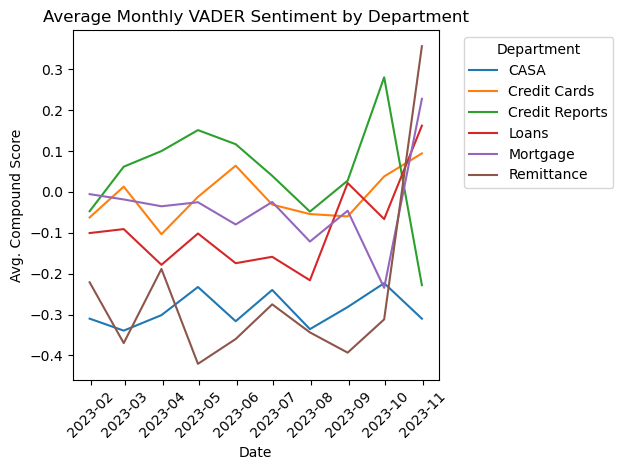

In [24]:
# 1) Ensure 'Date Received' is datetime
df['Date Received'] = pd.to_datetime(df['Date Received'], errors='coerce')

# 2) (Optional) confirm
print("Date Received dtype:", df['Date Received'].dtype)

# 3) Recompute VADER if needed
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
df['vader_compound'] = (
    df['Complaint Description']
      .fillna("")
      .apply(lambda t: analyzer.polarity_scores(t)['compound'])
)

# 4) Pivot monthly averages by department
monthly = df.pivot_table(
    index=pd.Grouper(key='Date Received', freq='M'),
    columns='department',
    values='vader_compound',
    aggfunc='mean'
)

# 5) Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for dept in monthly.columns:
    ax.plot(monthly.index, monthly[dept], label=dept)
ax.set_title("Average Monthly VADER Sentiment by Department")
ax.set_xlabel("Date")
ax.set_ylabel("Avg. Compound Score")
ax.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





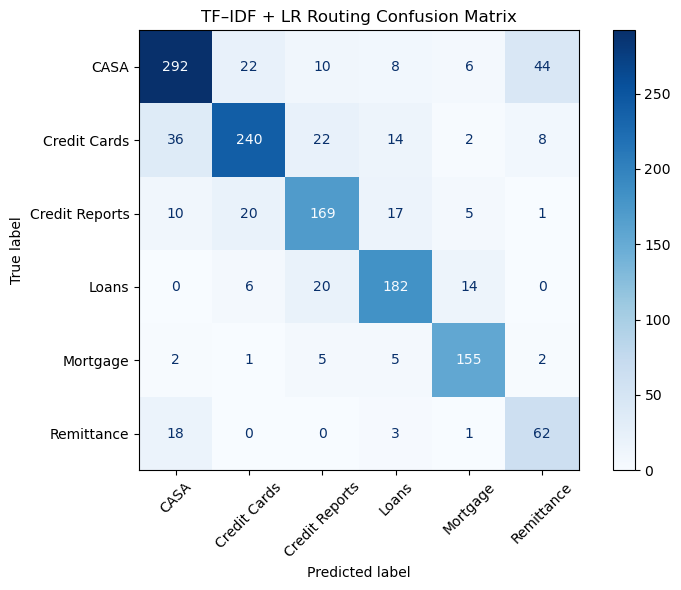

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Define your department labels in the same order as your classifier
labels = clf.classes_.tolist()  

# 2) Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 3) Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("TF–IDF + LR Routing Confusion Matrix")
plt.tight_layout()
plt.show()



In [27]:
from sklearn.pipeline       import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10_000)),
    ("clf",   LogisticRegression(class_weight="balanced", max_iter=1000)),
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__max_features": [5_000, 10_000, 20_000],
    "clf__C":              [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_text, y_train)

print("Best params:", grid.best_params_)
print(classification_report(y_test, grid.predict(X_test_text)))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'clf__C': 10, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
                precision    recall  f1-score   support

          CASA       0.78      0.80      0.79       382
  Credit Cards       0.82      0.76      0.79       322
Credit Reports       0.77      0.75      0.76       222
         Loans       0.82      0.84      0.83       222
      Mortgage       0.88      0.91      0.89       170
    Remittance       0.61      0.63      0.62        84

      accuracy                           0.79      1402
     macro avg       0.78      0.78      0.78      1402
  weighted avg       0.79      0.79      0.79      1402



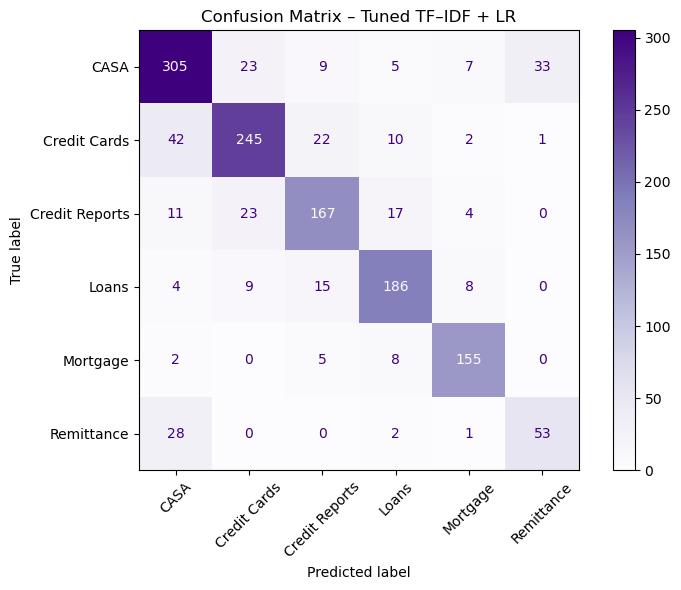

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Grab the best pipeline
best_pipe = grid.best_estimator_

# 2) Predict on X_test_text
y_pred_tuned = best_pipe.predict(X_test_text)

# 3) Confusion matrix
labels = best_pipe.named_steps["clf"].classes_
cm = confusion_matrix(y_test, y_pred_tuned, labels=labels)

disp = ConfusionMatrixDisplay(cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap="Purples", xticks_rotation=45)
ax.set_title("Confusion Matrix – Tuned TF–IDF + LR")
plt.tight_layout()
plt.show()


In [31]:


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

df['vader_compound'] = (
    df['Complaint Description']
      .fillna('')
      .apply(lambda t: analyzer.polarity_scores(t)['compound'])
)

df['vader_label'] = pd.cut(
    df['vader_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['negative','neutral','positive']
)

print(df['vader_label'].value_counts())


vader_label
negative    3819
positive    2873
neutral      318
Name: count, dtype: int64


/var/folders/_w/1v5jxkz56qxcjphx0msmcxr00000gn/T/ipykernel_26210/101523870.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")                             # “M” = month‐end


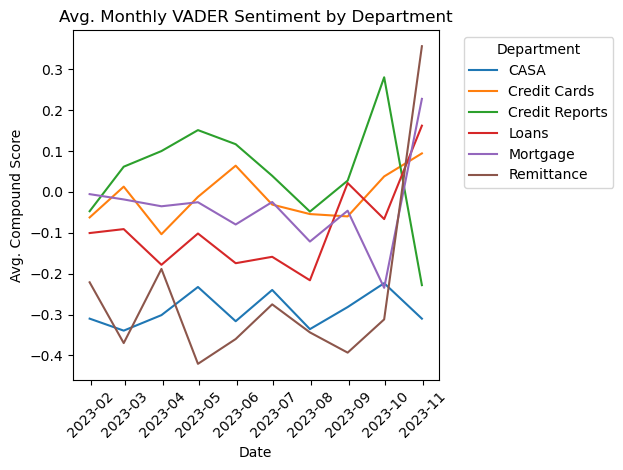

In [32]:
import matplotlib.pyplot as plt

# pivot to get monthly averages by department
monthly = (
    df
    .set_index("Date Received")                # use the datetime index
    .groupby("department")["vader_compound"]   # focus on the compound score
    .resample("M")                             # “M” = month‐end
    .mean()                                    # average over each month
    .unstack(level=0)                          # departments → columns
)

# plot
fig, ax = plt.subplots()
for dept in monthly.columns:
    ax.plot(
        monthly.index, 
        monthly[dept], 
        label=dept
    )
ax.set_title("Avg. Monthly VADER Sentiment by Department")
ax.set_xlabel("Date")
ax.set_ylabel("Avg. Compound Score")
ax.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocessing(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                      # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                  # remove punctuation
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # drop stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # lemmatize
    return ' '.join(tokens)

# apply
df['clean_text'] = df['Complaint Description'].fillna('').apply(preprocessing)
df[['Complaint Description','clean_text']].head()


In [ ]:
# already created df['clean_text']
X = df['clean_text']

# use the real column name  
y = df['department']

# drop missing targets
mask = y.notna()
X = X[mask]
y = y[mask]

# vectorize & split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection   import train_test_split

vectorizer = TfidfVectorizer(max_features=10_000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# train & evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics        import classification_report

clf = LogisticRegression(max_iter=1_000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))



In [ ]:
!pip install transformers torch

from transformers import pipeline

# get department list
departments = df['department'].unique().tolist()

# initialize using facebook/bart-large-mnli for multi-class zero-shot classifier
zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

# sample a few complaints to test
samples = df['Complaint Description']\
    .dropna()\
    .sample(5, random_state=42)\
    .tolist()

# classify into departments
results = zero_shot(samples, candidate_labels=departments)

# print each complaint with its top predicted department
for text, res in zip(samples, results):
    print("Complaint:", text[:80], "…")
    print("Predicted Dept:", res["labels"][0], f"(score={res['scores'][0]:.2f})\n")


In [ ]:
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# get compound score
df['vader_compound'] = df['Complaint Description'].fillna('').apply(
    lambda txt: analyzer.polarity_scores(txt)['compound']
)

# bucket into negative/neutral/positive
df['vader_label'] = pd.cut(
    df['vader_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['negative','neutral','positive']
)

df['vader_label'].value_counts()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import classification_report
from transformers               import pipeline

# 1) Split raw text & labels
X_text = df["Complaint Description"].fillna("")
y      = df["department"]
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# 2) TF-IDF + LogisticRegression
vectorizer = TfidfVectorizer(max_features=10_000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

clf = LogisticRegression(max_iter=1_000, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("TF–IDF + LR on department:\n")
print(classification_report(y_test, y_pred))

# 3) Zero-shot transformer
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
departments = y.unique().tolist()
results = zero_shot(X_test_text.tolist(), candidate_labels=departments)
pred_zero = [r["labels"][0] for r in results]

print("Zero-shot classification report:\n")
print(classification_report(y_test, pred_zero))


